# Generate AF-3 Splits
Interfactive notebook to generate and save AlphaFold-3-style train/validation splits for training deep learning models.
We use a notebook over a script to facilitate documentation and error detection.

## Training Datasets

### Separate Train/Validation datasets by date cutoff

In [1]:
import pandas as pd

# NOTE: The dataframes must have token information, i.e., the column "n_total_tokens", which can be created using the scripts in `splits`
pn_units_df_path = "/projects/ml/RF2_allatom/datasets/pdb/2024_09_10/pn_units_df_with_token_counts.parquet"
interfaces_df_path = "/projects/ml/RF2_allatom/datasets/pdb/2024_09_10/interfaces_df_with_token_counts.parquet"

# (We must load all columns, since we will later save out the dataframes to different paths)
pn_units_df = pd.read_parquet(pn_units_df_path)
interfaces_df = pd.read_parquet(interfaces_df_path)

> "The structure must have been released to the PDB before the cutoff date of 2021-09-30" - AF3 Supplement, p. 5

In [2]:
# ...define the training date cutoff
# (This is the "release date", not the "deposition date", which can differ by up to a year)
# From AF-3: "The structure must have been released to the PDB before the cutoff date of 2021-09-30"
TRAIN_DATE_CUTOFF = pd.to_datetime("2021-09-30")
OUT_DIR = "/projects/ml/RF2_allatom/datasets/af3_splits"

# ...get the PDB IDs of the proteins that were released before the cutoff
pdbs_before_cutoff = pn_units_df[pn_units_df["release_date"] < TRAIN_DATE_CUTOFF]["pdb_id"].unique()

# ...subselect the pn_units_df and interfaces_df to only include the proteins released before the cutoff
pn_units_df_train = pn_units_df[pn_units_df["pdb_id"].isin(pdbs_before_cutoff)]
interfaces_df_train = interfaces_df[interfaces_df["pdb_id"].isin(pdbs_before_cutoff)]
print(f"Training data: {len(pn_units_df_train):,} proteins, {len(interfaces_df_train):,} interfaces")

pn_units_df_val = pn_units_df[~pn_units_df["pdb_id"].isin(pdbs_before_cutoff)]
interfaces_df_val = interfaces_df[~interfaces_df["pdb_id"].isin(pdbs_before_cutoff)]
print(f"Candidate validation data: {len(pn_units_df_val):,} proteins, {len(interfaces_df_val):,} interfaces")

# ...remove rows without cluster information
pn_units_df_train = pn_units_df_train.dropna(subset=["cluster"])
interfaces_df_train = interfaces_df_train.dropna(subset=["cluster"])
print(
    f"Training data after removing proteins without cluster information: {len(pn_units_df_train):,} proteins, {len(interfaces_df_train):,} interfaces"
)

pn_units_df_val = pn_units_df_val.dropna(subset=["cluster"])
interfaces_df_val = interfaces_df_val.dropna(subset=["cluster"])
print(
    f"Candidate validation data after removing proteins without cluster information: {len(pn_units_df_val):,} proteins, {len(interfaces_df_val):,} interfaces"
)

# ...save out the training dataframes to disk
pn_units_df_train.to_parquet(f"{OUT_DIR}/pn_units_df_train.parquet")
interfaces_df_train.to_parquet(f"{OUT_DIR}/interfaces_df_train.parquet")

# ...save out the candidate validation dataframes to disk
# (The "candidate" validation dataframes are all examples that were not included in the training dataframes and are thus candidates for validation)
pn_units_df_val.to_parquet(f"{OUT_DIR}/pn_units_df_candidate_val.parquet")
interfaces_df_val.to_parquet(f"{OUT_DIR}/interfaces_df_candidate_val.parquet")

Training data: 2,614,189 proteins, 4,518,229 interfaces
Candidate validation data: 868,323 proteins, 1,703,156 interfaces
Training data after removing proteins without cluster information: 2,568,573 proteins, 4,443,361 interfaces
Candidate validation data after removing proteins without cluster information: 860,001 proteins, 1,688,541 interfaces


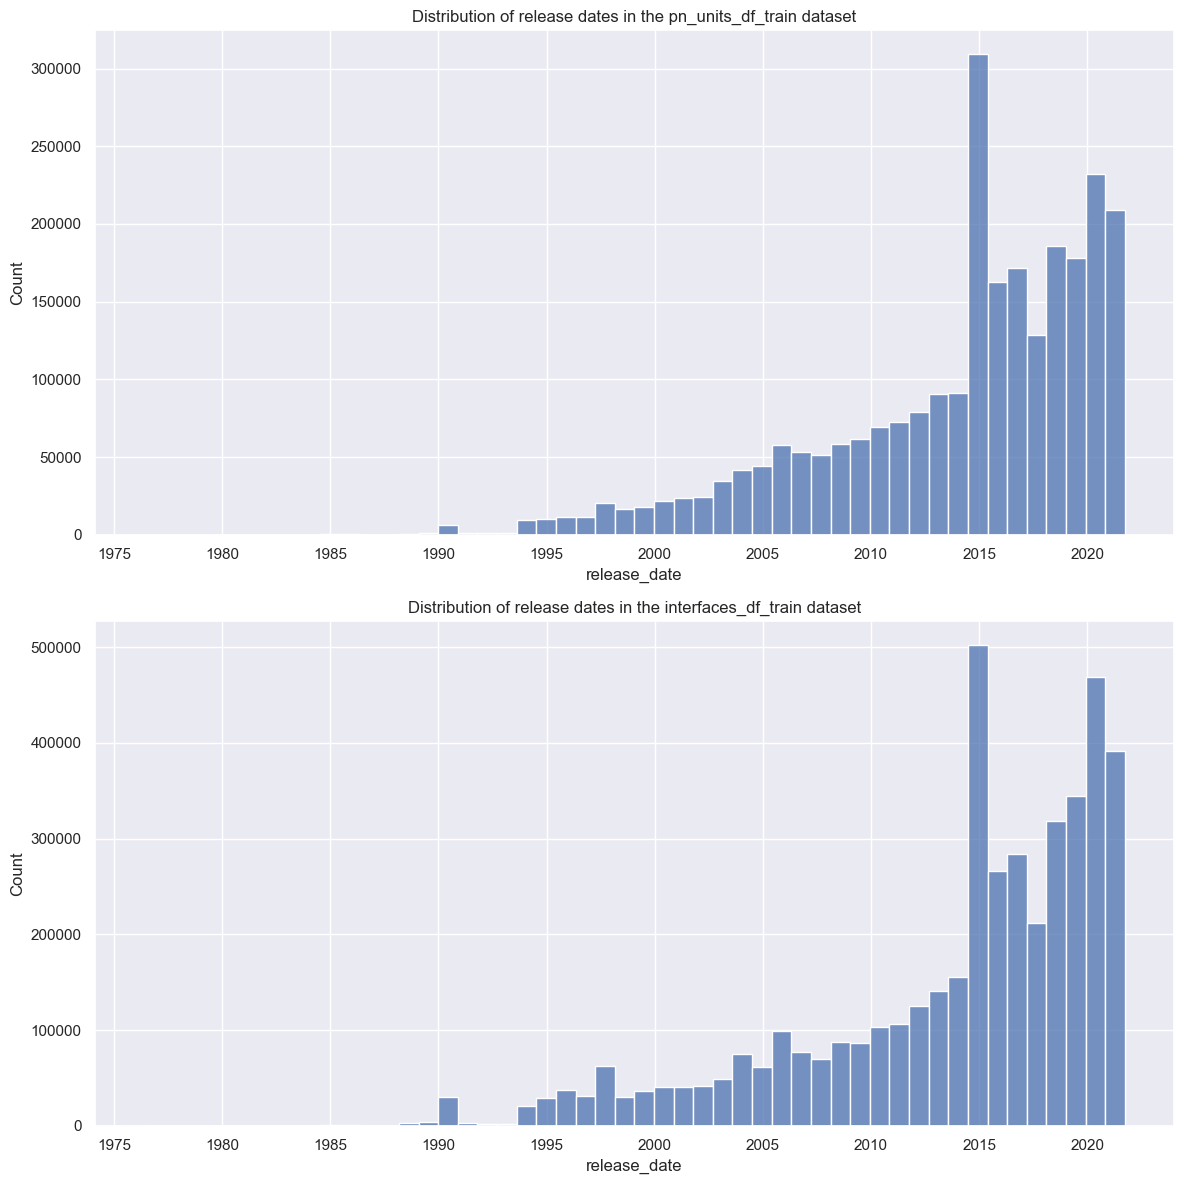

In [3]:
# ...visualize the distribution of release dates in the training data
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
sns.histplot(pn_units_df_train["release_date"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of release dates in the pn_units_df_train dataset")

# Plot the distribution of release dates in the interfaces_df_train dataset
sns.histplot(interfaces_df_train["release_date"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of release dates in the interfaces_df_train dataset")

# Adjust layout to prevent overlap
plt.tight_layout()

plt.show()

Now, we're done with the training datasets! Onto validation.

## Validation Datasets: Interfaces

### Step 1: Filter the validation dataset based on basic entry-level criteria

> "Take all targets released after 2021-09-30 and before 2023-01-13 and remove targets with total number of tokens greater than 2560, more than one thousand chains, or resolution greater than 4.5" - AF3 Supplement, p. 31

In [4]:
MIN_VAL_DATE = pd.to_datetime("2021-09-30")
MAX_VAL_DATE = pd.to_datetime("2023-01-13")
TOKEN_LIMIT = 2560
RESOLUTION_LIMIT = 4.5
CHAIN_LIMIT = 1000

print(f"Number of rows prior to filtering: {len(interfaces_df_val):,}")

# ...filter to only inclues rows within the interfaces dataframe that are within the validation date range
candidate_interfaces_df_val = interfaces_df_val[
    (interfaces_df_val["release_date"] > MIN_VAL_DATE) & (interfaces_df_val["release_date"] < MAX_VAL_DATE)
]
print(f"Number of rows within validation date range: {len(candidate_interfaces_df_val ):,}")

# ...assert that there are no rows with a release date outside of the validation date range
assert candidate_interfaces_df_val["release_date"].min() > MIN_VAL_DATE
assert candidate_interfaces_df_val["release_date"].max() < MAX_VAL_DATE

# ...filter again to only include rows with fewer than 2,560 tokens
candidate_interfaces_df_val = candidate_interfaces_df_val[candidate_interfaces_df_val["n_tokens_total"] < TOKEN_LIMIT]
print(f"Number of rows within validation date range and token limit: {len(candidate_interfaces_df_val ):,}")

# ...assert that there are no rows with more than 2,560 tokens
assert candidate_interfaces_df_val["n_tokens_total"].max() < TOKEN_LIMIT

# ...filter once more to only include rows with a resolution greater than 4.5 angstrom
candidate_interfaces_df_val = candidate_interfaces_df_val[candidate_interfaces_df_val["resolution"] < RESOLUTION_LIMIT]
print(
    f"Number of rows within validation date range, token limit, and resolution limit: {len(candidate_interfaces_df_val):,}"
)
assert candidate_interfaces_df_val["resolution"].max() < RESOLUTION_LIMIT

# ...filter to examples with fewer than 1,000 chains
candidate_interfaces_df_val = candidate_interfaces_df_val[
    candidate_interfaces_df_val["num_polymer_pn_units"] < CHAIN_LIMIT
]
print(
    f"Number of rows within validation date range, token limit, resolution limit, and chain limit: {len(candidate_interfaces_df_val):,}"
)
assert candidate_interfaces_df_val["num_polymer_pn_units"].max() < CHAIN_LIMIT

Number of rows prior to filtering: 1,688,541
Number of rows within validation date range: 707,117
Number of rows within validation date range and token limit: 130,170
Number of rows within validation date range, token limit, and resolution limit: 126,673
Number of rows within validation date range, token limit, resolution limit, and chain limit: 126,673


Text(0.5, 1.0, 'Distribution of release dates in the deduplicated_interfaces_df_val dataset')

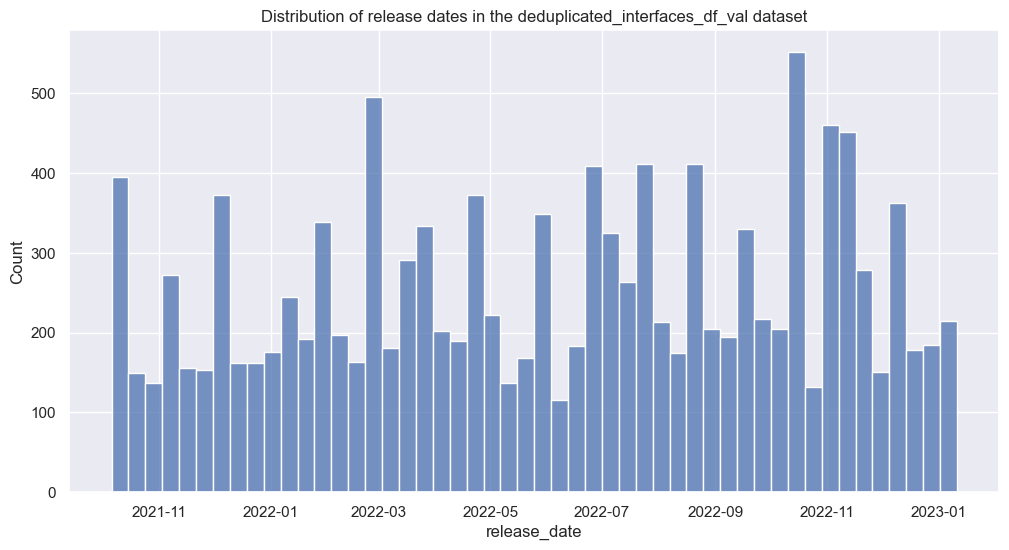

In [5]:
# Create a plot of candidate interfaces by release date
import matplotlib.pyplot as plt
import seaborn

# ...create a new dataframe that is deduplicated by "pdb_id" (for visualization purposes)
deduplicated_interfaces_df_val = candidate_interfaces_df_val.drop_duplicates(subset="pdb_id")

# Plot the distribution of release dates in the deduplicated_interfaces_df_val dataset
seaborn.set_theme()
fig, ax = plt.subplots(figsize=(12, 6))
seaborn.histplot(deduplicated_interfaces_df_val["release_date"], bins=50, ax=ax)

# Set the title and labels
ax.set_title("Distribution of release dates in the deduplicated_interfaces_df_val dataset")

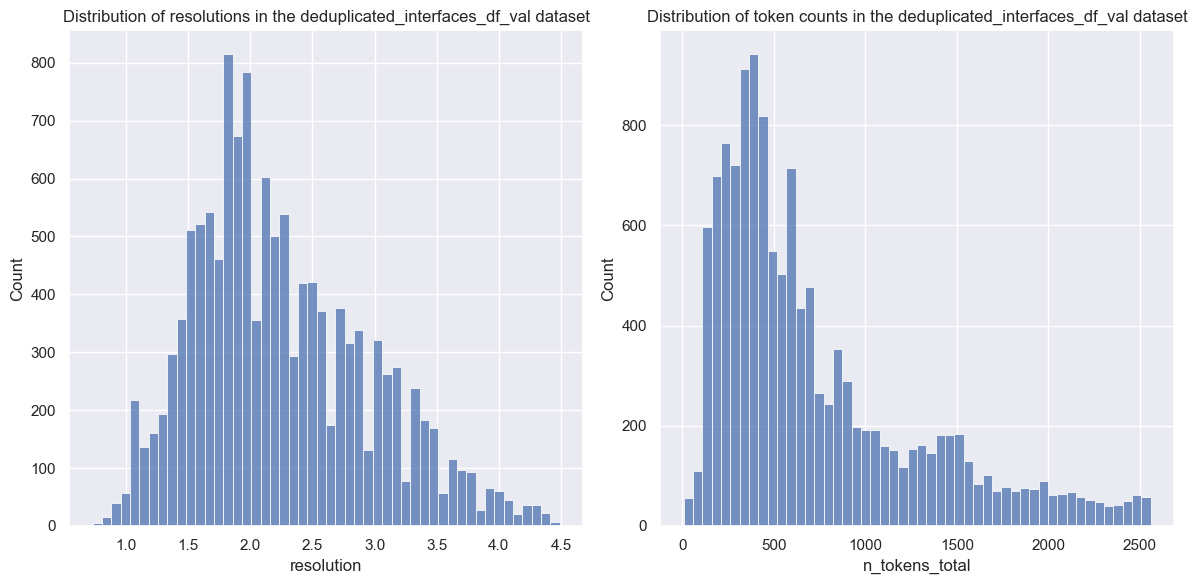

In [6]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the distribution of resolutions in the deduplicated_interfaces_df_val dataset
sns.histplot(deduplicated_interfaces_df_val["resolution"], bins=50, ax=axes[0])

# Plot the distribution of token counts in the deduplicated_interfaces_df_val dataset
axes[0].set_title("Distribution of resolutions in the deduplicated_interfaces_df_val dataset")
sns.histplot(deduplicated_interfaces_df_val["n_tokens_total"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of token counts in the deduplicated_interfaces_df_val dataset")
plt.tight_layout()

plt.show()

### Step 2: Filter to low-homology interfaces

> Filter to only low homology interfaces, which are defined as those where no target in the training set contains
two chains with high homology to the chains involved in the interface, where high homology here means >
40% sequence identity for polymers or > 0.85 tanimoto similarity for ligands. Additionally filter out interfaces
involving a ligand with ranking model fit less than 0.5 or with multiple residues - AF3 Supplement, p. 31

Accomplishing this task of filtering to low-homology interfaces is somewhat trickier. Our output to this step will be the `interfaces_df`, only containing rows that:
- Contain one `pn_unit` which we determine is *dissimilar* from all `pn_units` within the train site of its respective type (same 40% sequence identity cluster for proteins, 0.85 tanimoto similarity for ligands)
- Do not involve a ligand with ranking model fit less than 0.5
- Do not involve a ligand with multiple residues

First, we filter out interfaces involving a ligand with multiple residues or multiple chains, since they're nasty to work with...

In [7]:
from cifutils.enums import ChainType

# ...remove examples where `pn_unit_1` is a non-polymer but is multi-residue
candidate_interfaces_df_val = candidate_interfaces_df_val[
    ~(
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
        & (
            candidate_interfaces_df_val["pn_unit_1_is_multiresidue"]
            | candidate_interfaces_df_val["pn_unit_1_is_multichain"]
        )
    )
]

# ...and the same for `pn_unit_2`
print(
    f"Number of rows in the candidate_interfaces_df_val dataset prior to filtering out non-polymer multi-residue chains: {len(candidate_interfaces_df_val):,}"
)
candidate_interfaces_df_val = candidate_interfaces_df_val[
    ~(
        (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
        & (
            candidate_interfaces_df_val["pn_unit_2_is_multiresidue"]
            | candidate_interfaces_df_val["pn_unit_2_is_multichain"]
        )
    )
]
print(
    f"Number of rows in the candidate_interfaces_df_val dataset after filtering out non-polymer multi-residue chains: {len(candidate_interfaces_df_val):,}"
)

Number of rows in the candidate_interfaces_df_val dataset prior to filtering out non-polymer multi-residue chains: 126,339
Number of rows in the candidate_interfaces_df_val dataset after filtering out non-polymer multi-residue chains: 123,265


We must also throw out interfaces that involve a ligand with ranking model fit less than 0.5 (which is, by definition, half of the ligands annotated with fit-to-density). We only have fit-to-density in the PN Units DF, so must work with that dataframe for the moment.

In [8]:
import numpy as np

FIT_TO_DENSITY_CUTOFF = 0.5

# ...subset to only non-polymers
candidate_pn_units_df_non_polymers = pn_units_df_val[pn_units_df_val["q_pn_unit_type"] == ChainType.NON_POLYMER.value]

# ...record the PDB IDs and pn_unit IIDs that fail the criteria
ligands_that_fail_criteria = set()
num_with_no_ligand_validity = 0
num_below_cutoff = 0

# ...loop through the non-polymers and note the pn_units that do NOT meet the criteria (we will later remove them from the interfaces and pn_units dataframes)
for row in candidate_pn_units_df_non_polymers.itertuples():
    # ...eval the "q_pn_unit_ligand_validity" column
    try:
        ligand_validity = eval(row.q_pn_unit_ligand_validity, {"nan": np.nan})
    except Exception as e:
        print(f"Error evaluating ligand validity for {row.pdb_id} {row.q_pn_unit_chain_id}: {e}")
        ligand_validity = None

    ranking_model_fit = (
        # Heinous expression to evaluate the the string representation and extract the ranking model fit (there should only be one ligand represented, since we already removed multi-residue ligands))
        list(eval(row.q_pn_unit_ligand_validity, {"nan": np.nan})["ranking_model_fit"].values())[0]
        if ligand_validity
        and "ranking_model_fit" in ligand_validity
        and ligand_validity["ranking_model_fit"]
        and len(ligand_validity["ranking_model_fit"]) == 1
        else None
    )

    # ...if the ranking model is not present, or is below the cutoff, add the PDB ID and the pn_unit IID to the set to of examples to remove
    if not ranking_model_fit:
        num_with_no_ligand_validity += 1
        ligands_that_fail_criteria.add(tuple([row.pdb_id, row.q_pn_unit_iid]))
    elif ranking_model_fit < FIT_TO_DENSITY_CUTOFF:
        num_below_cutoff += 1
        ligands_that_fail_criteria.add(tuple([row.pdb_id, row.q_pn_unit_iid]))

print(f"Number of rows with no or null ranking model fit: {num_with_no_ligand_validity:,}")
print(f"Number of rows with ranking model fit below cutoff: {num_below_cutoff:,}")

Number of rows with no or null ranking model fit: 272,931
Number of rows with ranking model fit below cutoff: 119,139


In [9]:
# Remove the ligands that do not meet the fit-to-density criteria from the candidate_interfaces_df_val
print(
    f"Number of rows in the candidate_interfaces_df_val dataset before filtering out ligands that do not meet fit-to-density criteria: {len(candidate_interfaces_df_val):,}"
)
interfaces_df_mask = candidate_interfaces_df_val.apply(
    lambda row: (row["pdb_id"], row["pn_unit_1_iid"]) not in ligands_that_fail_criteria, axis=1
)
interfaces_df_mask &= candidate_interfaces_df_val.apply(
    lambda row: (row["pdb_id"], row["pn_unit_2_iid"]) not in ligands_that_fail_criteria, axis=1
)
candidate_interfaces_df_val = candidate_interfaces_df_val[interfaces_df_mask]
print(
    f"Number of rows in the candidate_interfaces_df_val dataset after filtering out ligands that do not meet fit-to-density criteria: {len(candidate_interfaces_df_val):,}"
)

Number of rows in the candidate_interfaces_df_val dataset before filtering out ligands that do not meet fit-to-density criteria: 123,265
Number of rows in the candidate_interfaces_df_val dataset after filtering out ligands that do not meet fit-to-density criteria: 82,529


And finally we filter out low-homology interfaces. To review, we define low-homology as containing one `pn_unit` which we consider *dissimilar* from all `pn_units` within the train site of its respective type (same 40% sequence identity cluster for proteins, 0.85 tanimoto similarity for ligands)

In [10]:
import pickle

# Remove non-polymer rows where a ligand name is not in our similarity to train set map (i.e., the ligand was not sanitized by RDKit)
# ...load the tanimoto similarity to any ligand in the training set lookup dictionary (NOTE: This dictionary can be created using the `build_residue_by_residue_tanimoto_similarity_map.py` script in the `clustering` scripts directory)
residue_to_max_similarity_train_set_path = (
    "/projects/ml/RF2_allatom/datasets/af3_splits/tanimoto_similarity_with_train_set.pkl"
)
with open(residue_to_max_similarity_train_set_path, "rb") as f:
    residue_to_max_similarity_to_train_set = pickle.load(f)

# ...get the ligand names that are in the lookup dictionary
ligand_names = set(residue_to_max_similarity_to_train_set.keys())

# ...filter the candidate_interfaces_df_val to only include rows where both ligand names are in the lookup dictionary (or where the chain type is not a non-polymer)
print(
    f"Number of rows in the candidate_interfaces_df_val dataset before filtering out ligands not in the lookup map: {len(candidate_interfaces_df_val ):,}"
)
candidate_interfaces_df_val = candidate_interfaces_df_val[
    (
        candidate_interfaces_df_val["pn_unit_1_non_polymer_res_names"].isin(ligand_names)
        | (candidate_interfaces_df_val["pn_unit_1_type"] != ChainType.NON_POLYMER.value)
    )
    & (
        candidate_interfaces_df_val["pn_unit_2_non_polymer_res_names"].isin(ligand_names)
        | (candidate_interfaces_df_val["pn_unit_2_type"] != ChainType.NON_POLYMER.value)
    )
]
# (This filter should not remove very many rows (~1% maximum); if it does, it may indicate that the residue names were not sanitized correctly)
print(
    f"Number of rows in the candidate_interfaces_df_val dataset after filtering out ligands not in the lookup map: {len(candidate_interfaces_df_val ):,}"
)

Number of rows in the candidate_interfaces_df_val dataset before filtering out ligands not in the lookup map: 82,529
Number of rows in the candidate_interfaces_df_val dataset after filtering out ligands not in the lookup map: 82,471


In [11]:
TANIMOTO_SIMILARITY_CUTOFF = 0.85

# ...get all of the protein clusters in the training set, which are clustered by 40% sequence identity for proteins, 100% sequence identity for nucelic acids, 100% sequence identity for small peptides, and CCD identity for ligands
train_clusters = set(pn_units_df_train["cluster"].unique())

# ...iterate through all interfaces
# We keep the interface ONLY IF:
# - One of the two pn_units involved in the interface does not closely resemble any PN Units in the training set of the same type

interfaces_to_remove = set()
for row in candidate_interfaces_df_val.itertuples():
    match row.pn_unit_1_type:
        case ChainType.NON_POLYMER.value:
            # ...check if the non-polymer is similar to any non-polymers in the training set (excluding the ligand in the case of a fallback)
            pn_unit_1_is_novel = (
                residue_to_max_similarity_to_train_set.get(row.pn_unit_1_non_polymer_res_names, 1)
                < TANIMOTO_SIMILARITY_CUTOFF
            )
        case _:
            # ...check if the polymer is similar to any polymer in the training set (i.e., based on 40% sequence identity cluster for proteins)
            pn_unit_1_is_novel = row.pn_unit_1_cluster not in train_clusters

    match row.pn_unit_2_type:
        case ChainType.NON_POLYMER.value:
            # ...check if the non-polymer is similar to any non-polymers in the training set (excluding the ligand in the case of a fallback)
            pn_unit_2_is_novel = (
                residue_to_max_similarity_to_train_set.get(row.pn_unit_2_non_polymer_res_names, 1)
                < TANIMOTO_SIMILARITY_CUTOFF
            )
        case _:
            # ...check if the polymer is similar to any polymer in the training set (i.e., based on 40% sequence identity cluster for proteins)
            pn_unit_2_is_novel = row.pn_unit_2_cluster not in train_clusters

    if pn_unit_1_is_novel or pn_unit_2_is_novel:
        # Keep
        continue
    else:
        interfaces_to_remove.add((row.pdb_id, row.pn_unit_1_iid, row.pn_unit_2_iid))

print(f"Number of interfaces: {len(candidate_interfaces_df_val):,}")
print(f"Number of interfaces to remove: {len(interfaces_to_remove):,}")

Number of interfaces: 82,471
Number of interfaces to remove: 58,351


In [12]:
# ...remove the interfaces that closely resemble training set examples
interfaces_df_mask = candidate_interfaces_df_val.apply(
    lambda row: (row["pdb_id"], row["pn_unit_1_iid"], row["pn_unit_2_iid"]) not in interfaces_to_remove, axis=1
)
candidate_interfaces_df_val_after_filter = candidate_interfaces_df_val[interfaces_df_mask]
print(
    f"Number of rows in the candidate_interfaces_df_val dataset after filtering out interfaces that closely resemble training set examples: {len(candidate_interfaces_df_val_after_filter):,}"
)

Number of rows in the candidate_interfaces_df_val dataset after filtering out interfaces that closely resemble training set examples: 24,014


### Step 3: Sample the interface validation set

Hurrah, we have out interfaces validation set! Now, we just need to sample:

> Take the following interface types only, possibly reducing number of clusters by sampling a subset of clusters
(number of samples given in brackets if reduced): protein-protein (600), protein-DNA (100), DNA-DNA (100),
Protein-ligand (600), DNA-ligand (50), ligand-ligand (200), protein-RNA, RNA-RNA, DNA-RNA, RNA-ligand.

In [13]:
# Define a dictionary to hold our final splits
final_interface_validation_splits = {
    "protein-protein": [],
    "protein-DNA": [],
    "DNA-DNA": [],
    "protein-ligand": [],
    "DNA-ligand": [],
    "ligand-ligand": [],
    "protein-RNA": [],
    "RNA-RNA": [],
    "DNA-RNA": [],
    "RNA-ligand": [],
}

In [14]:
import random
import numpy as np

# Set deterministic seeds
random.seed(42)
np.random.seed(42)

NUM_PROTEIN_PROTEIN_CLUSTERS_TO_SAMPLE = 600

# ...sample 600 protein-protein clusters
protein_protein_interfaces = candidate_interfaces_df_val[
    (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.POLYPEPTIDE_L.value)
    & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.POLYPEPTIDE_L.value)
]
print(f"Number of protein-protein interfaces: {len(protein_protein_interfaces):,}")
protein_protein_interface_clusters = protein_protein_interfaces["cluster"].unique()
print(f"Number of unique protein-protein clusters: {len(protein_protein_interface_clusters):,}")

# Sample 600 protein-protein interface clusters
selected_protein_protein_clusters = random.sample(
    list(protein_protein_interface_clusters), NUM_PROTEIN_PROTEIN_CLUSTERS_TO_SAMPLE
)

# Select one interface from each cluster
for cluster in selected_protein_protein_clusters:
    cluster_interfaces = protein_protein_interfaces[protein_protein_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    final_interface_validation_splits["protein-protein"].append(selected_interface)

Number of protein-protein interfaces: 32,551
Number of unique protein-protein clusters: 5,333


In [15]:
# Count the number of protein-DNA interfaces
NUM_PROTEIN_DNA_CLUSTERS_TO_SAMPLE = 100

protein_dna_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.POLYPEPTIDE_L.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.DNA.value)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.DNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.POLYPEPTIDE_L.value)
    )
]
print(f"Number of protein-DNA interfaces: {len(protein_dna_interfaces):,}")

# Count the number of protein-DNA clusters
print(f"Number of unique protein-DNA clusters: {len(protein_dna_interfaces['cluster'].unique()):,}")

# Sample 100 protein-DNA interface clusters
selected_protein_dna_clusters = random.sample(
    list(protein_dna_interfaces["cluster"].unique()), NUM_PROTEIN_DNA_CLUSTERS_TO_SAMPLE
)
for cluster in selected_protein_dna_clusters:
    cluster_interfaces = protein_dna_interfaces[protein_dna_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    final_interface_validation_splits["protein-DNA"].append(selected_interface)

Number of protein-DNA interfaces: 3,033
Number of unique protein-DNA clusters: 780


In [16]:
# Same thing with DNA-DNA
NUM_DNA_DNA_CLUSTERS_TO_SAMPLE = 100

dna_dna_interfaces = candidate_interfaces_df_val[
    (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.DNA.value)
    & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.DNA.value)
]
print(f"Number of DNA-DNA interfaces: {len(dna_dna_interfaces):,}")
print(f"Number of unique DNA-DNA clusters: {len(dna_dna_interfaces['cluster'].unique()):,}")

selected_dna_dna_clusters = random.sample(list(dna_dna_interfaces["cluster"].unique()), NUM_DNA_DNA_CLUSTERS_TO_SAMPLE)
dna_dna_validation_interfaces = []
for cluster in selected_dna_dna_clusters:
    cluster_interfaces = dna_dna_interfaces[dna_dna_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    final_interface_validation_splits["DNA-DNA"].append(selected_interface)

Number of DNA-DNA interfaces: 2,372
Number of unique DNA-DNA clusters: 436


In [17]:
# Protein-ligand
NUM_PROTEIN_LIGAND_CLUSTERS_TO_SAMPLE = 600

protein_ligand_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.POLYPEPTIDE_L.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.POLYPEPTIDE_L.value)
    )
]
print(f"Number of protein-ligand interfaces: {len(protein_ligand_interfaces):,}")
print(f"Number of unique protein-ligand clusters: {len(protein_ligand_interfaces['cluster'].unique()):,}")

# Sample 600 protein-ligand interface clusters
selected_protein_ligand_clusters = random.sample(
    list(protein_ligand_interfaces["cluster"].unique()), NUM_PROTEIN_LIGAND_CLUSTERS_TO_SAMPLE
)
for cluster in selected_protein_ligand_clusters:
    cluster_interfaces = protein_ligand_interfaces[protein_ligand_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    final_interface_validation_splits["protein-ligand"].append(selected_interface)

Number of protein-ligand interfaces: 34,036
Number of unique protein-ligand clusters: 6,323


In [18]:
# DNA-ligand
NUM_DNA_LIGAND_CLUSTERS_TO_SAMPLE = 50

dna_ligand_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.DNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.DNA.value)
    )
]
print(f"Number of DNA-ligand interfaces: {len(dna_ligand_interfaces):,}")
print(f"Number of unique DNA-ligand clusters: {len(dna_ligand_interfaces['cluster'].unique()):,}")

# We only have 23 DNA-ligand clusters, so we will sample 20 of them
selected_dna_ligand_clusters = random.sample(
    list(dna_ligand_interfaces["cluster"].unique()), NUM_DNA_LIGAND_CLUSTERS_TO_SAMPLE
)
for cluster in selected_dna_ligand_clusters:
    cluster_interfaces = dna_ligand_interfaces[dna_ligand_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    final_interface_validation_splits["DNA-ligand"].append(selected_interface)

Number of DNA-ligand interfaces: 1,268
Number of unique DNA-ligand clusters: 266


In [19]:
# Ligand-ligand
NUM_LIGAND_LIGAND_CLUSTERS_TO_SAMPLE = 200

ligand_ligand_interfaces = candidate_interfaces_df_val[
    (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
    & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
]
print(f"Number of ligand-ligand interfaces: {len(ligand_ligand_interfaces):,}")
print(f"Number of unique ligand-ligand clusters: {len(ligand_ligand_interfaces['cluster'].unique()):,}")

Number of ligand-ligand interfaces: 7,277
Number of unique ligand-ligand clusters: 1,269


In [20]:
# Protein-RNA
NUM_PROTEIN_RNA_CLUSTERS_TO_SAMPLE = (
    394  # AF-3 doesn't specify how many protein-RNA clusters to sample; we will take all of them (394)
)

protein_rna_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.POLYPEPTIDE_L.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.RNA.value)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.RNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.POLYPEPTIDE_L.value)
    )
]
print(f"Number of protein-RNA interfaces: {len(protein_rna_interfaces):,}")
print(f"Number of unique protein-RNA clusters: {len(protein_rna_interfaces['cluster'].unique()):,}")

selected_protein_rna_clusters = random.sample(
    list(protein_rna_interfaces["cluster"].unique()), NUM_PROTEIN_RNA_CLUSTERS_TO_SAMPLE
)
for cluster in selected_protein_rna_clusters:
    cluster_interfaces = protein_rna_interfaces[protein_rna_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    final_interface_validation_splits["protein-RNA"].append(selected_interface)

Number of protein-RNA interfaces: 853
Number of unique protein-RNA clusters: 394


In [21]:
# RNA-RNA
NUM_RNA_RNA_CLUSTERS_TO_SAMPLE = (
    110  # AF-3 doesn't specify how many RNA-RNA clusters to sample; we will take all of them (110)
)

rna_rna_interfaces = candidate_interfaces_df_val[
    (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.RNA.value)
    & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.RNA.value)
]
print(f"Number of RNA-RNA interfaces: {len(rna_rna_interfaces):,}")
print(f"Number of unique RNA-RNA clusters: {len(rna_rna_interfaces['cluster'].unique()):,}")

selected_rna_rna_clusters = random.sample(list(rna_rna_interfaces["cluster"].unique()), NUM_RNA_RNA_CLUSTERS_TO_SAMPLE)
for cluster in selected_rna_rna_clusters:
    cluster_interfaces = rna_rna_interfaces[rna_rna_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    final_interface_validation_splits["RNA-RNA"].append(selected_interface)

Number of RNA-RNA interfaces: 276
Number of unique RNA-RNA clusters: 110


In [22]:
# DNA-RNA
NUM_DNA_RNA_CLUSTERS_TO_SAMPLE = (
    67  # AF-3 doesn't specify how many DNA-RNA clusters to sample; we will take all of them (67)
)

dna_rna_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.DNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.RNA.value)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.RNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.DNA.value)
    )
]
print(f"Number of DNA-RNA interfaces: {len(dna_rna_interfaces):,}")
print(f"Number of unique DNA-RNA clusters: {len(dna_rna_interfaces['cluster'].unique()):,}")

selected_dna_rna_clusters = random.sample(list(dna_rna_interfaces["cluster"].unique()), NUM_DNA_RNA_CLUSTERS_TO_SAMPLE)
for cluster in selected_dna_rna_clusters:
    cluster_interfaces = dna_rna_interfaces[dna_rna_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    final_interface_validation_splits["DNA-RNA"].append(selected_interface)

Number of DNA-RNA interfaces: 95
Number of unique DNA-RNA clusters: 67


In [23]:
# RNA-ligand
NUM_RNA_LIGAND_CLUSTERS_TO_SAMPLE = (
    105  # AF-3 doesn't specify how many RNA-ligand clusters to sample; we will take all of them (105)
)

rna_ligand_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.RNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.RNA.value)
    )
]
print(f"Number of RNA-ligand interfaces: {len(rna_ligand_interfaces):,}")
print(f"Number of unique RNA-ligand clusters: {len(rna_ligand_interfaces['cluster'].unique()):,}")

selected_rna_ligand_clusters = random.sample(
    list(rna_ligand_interfaces["cluster"].unique()), NUM_RNA_LIGAND_CLUSTERS_TO_SAMPLE
)
for cluster in selected_rna_ligand_clusters:
    cluster_interfaces = rna_ligand_interfaces[rna_ligand_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    final_interface_validation_splits["RNA-ligand"].append(selected_interface)

Number of RNA-ligand interfaces: 631
Number of unique RNA-ligand clusters: 105


## Validation Data: Monomers

In [24]:
MIN_VAL_DATE = pd.to_datetime("2021-09-30")
MAX_VAL_DATE = pd.to_datetime("2023-01-13")
TOKEN_LIMIT = 2560
RESOLUTION_LIMIT = 4.5
CHAIN_LIMIT = 1000

print(f"Number of rows prior to filtering: {len(pn_units_df_val):,}")

# ...filter to only inclues rows within the PN Units dataframe that are within the validation date range
candidate_pn_units_df_val = pn_units_df_val[
    (pn_units_df_val["release_date"] > MIN_VAL_DATE) & (pn_units_df_val["release_date"] < MAX_VAL_DATE)
]
print(f"Number of rows within validation date range: {len(candidate_pn_units_df_val ):,}")

# ...assert that there are no rows with a release date outside of the validation date range
assert candidate_pn_units_df_val["release_date"].min() > MIN_VAL_DATE
assert candidate_pn_units_df_val["release_date"].max() < MAX_VAL_DATE

# ...filter again to only include rows with fewer than 2,560 tokens
candidate_pn_units_df_val = candidate_pn_units_df_val[candidate_pn_units_df_val["n_tokens_total"] < TOKEN_LIMIT]
print(f"Number of rows within validation date range and token limit: {len(candidate_pn_units_df_val ):,}")

# ...assert that there are no rows with more than 2,560 tokens
assert candidate_pn_units_df_val["n_tokens_total"].max() < TOKEN_LIMIT

# ...filter once more to only include rows with a resolution greater than 4.5 angstrom
candidate_pn_units_df_val = candidate_pn_units_df_val[candidate_pn_units_df_val["resolution"] < RESOLUTION_LIMIT]
print(
    f"Number of rows within validation date range, token limit, and resolution limit: {len(candidate_pn_units_df_val ):,}"
)
assert candidate_pn_units_df_val["resolution"].max() < RESOLUTION_LIMIT

# ...filter to examples with fewer than 1,000 chains
candidate_pn_units_df_val = candidate_pn_units_df_val[candidate_pn_units_df_val["num_polymer_pn_units"] < CHAIN_LIMIT]
print(
    f"Number of rows within validation date range, token limit, resolution limit, and chain limit: {len(candidate_pn_units_df_val ):,}"
)
assert candidate_pn_units_df_val["num_polymer_pn_units"].max() < CHAIN_LIMIT

Number of rows prior to filtering: 860,001
Number of rows within validation date range: 353,527
Number of rows within validation date range and token limit: 104,406
Number of rows within validation date range, token limit, and resolution limit: 102,088
Number of rows within validation date range, token limit, resolution limit, and chain limit: 102,088


Filter to low-homology polymers (i.e., a cluster not seen during training)

In [31]:
# ...filter to polymers
polymer_chain_type_ints = [chain_type.value for chain_type in ChainType.get_polymers()]
candidate_interfaces_df_val_polymers = candidate_pn_units_df_val[
    candidate_pn_units_df_val["q_pn_unit_type"].isin(polymer_chain_type_ints)
]

print(
    f"Number of rows in the candidate_pn_units_df_val dataset before filtering out non-polymers: {len(candidate_pn_units_df_val):,}"
)
print(candidate_interfaces_df_val_polymers["q_pn_unit_type"].value_counts())
print(f"Number of rows after filtering out non-polymers: {len(candidate_pn_units_df_val):,}")

Number of rows in the candidate_pn_units_df_val dataset before filtering out non-polymers: 102,088
6    41337
3     2277
7      851
4       20
5       16
Name: q_pn_unit_type, dtype: int64
Number of rows after filtering out non-polymers: 102,088


In [ ]:
# ...remove polymers that are similar to any polymers in the training set
clusters_in_training_set = set(pn_units_df_train["cluster"].unique())